# Autonomous Production Choke Controller — Problem 3A

**Honeywell Hackathon · single naturally flowing oil well · Ts = 1 hr**

This notebook is a narrative walk-through of the solution: from the raw step-test
data, through dynamic model identification and the operating envelope, to the
safety-first predictive controller and the three required demonstration
scenarios (A, B, C).

**Goal.** Every hour, set the production choke (0–100 %) to track a target oil
rate while *never* violating the pressure envelope (lower bounds on WHP/FLP/BHP)
or the ±5 %/step ramp limit. If a target is unsafe, settle at the maximum
achievable safe rate instead of chasing it.

The reusable logic lives in flat modules (`dataio`, `model_id`, `envelope`,
`simulator`, `controller`, `plotting`, `scenarios`); here we import and narrate
them.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # make the flat modules importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataio import load_step_test, to_canonical, infer_sample_time, OUTPUTS
from model_id import identify_all, free_run, validation_fit, format_report
from envelope import DEFAULT_ENVELOPE as ENV
from simulator import WellSimulator, STARTUP_CHOKE, STARTUP_STATE
from controller import ChokeMPC, NaiveController
from scenarios import run_all_mpc, run_all_baseline

pd.set_option('display.precision', 3)

## 1. The step-test data

A 120-hour open-loop step test: the choke is stepped 30 → 40 → 55 → 45 → 65 %
and the well's oil rate and three pressures are recorded each hour.

In [2]:
df = load_step_test()
ts = infer_sample_time(df)
print(f"{len(df)} rows, Ts = {ts} hr")
df.head()

120 rows, Ts = 1.0 hr


,Time_hr,Choke_pct,OilRate_bbl_hr,WHP_psi,FLP_psi,BHP_psi
0,0,30,90.00,250.00,180.00,3000.00
1,1,30,91.12,252.54,181.72,3017.37
2,2,30,91.45,254.71,183.67,3031.08
3,3,30,91.53,257.17,184.33,3040.00
4,4,30,92.17,257.61,184.26,3047.91


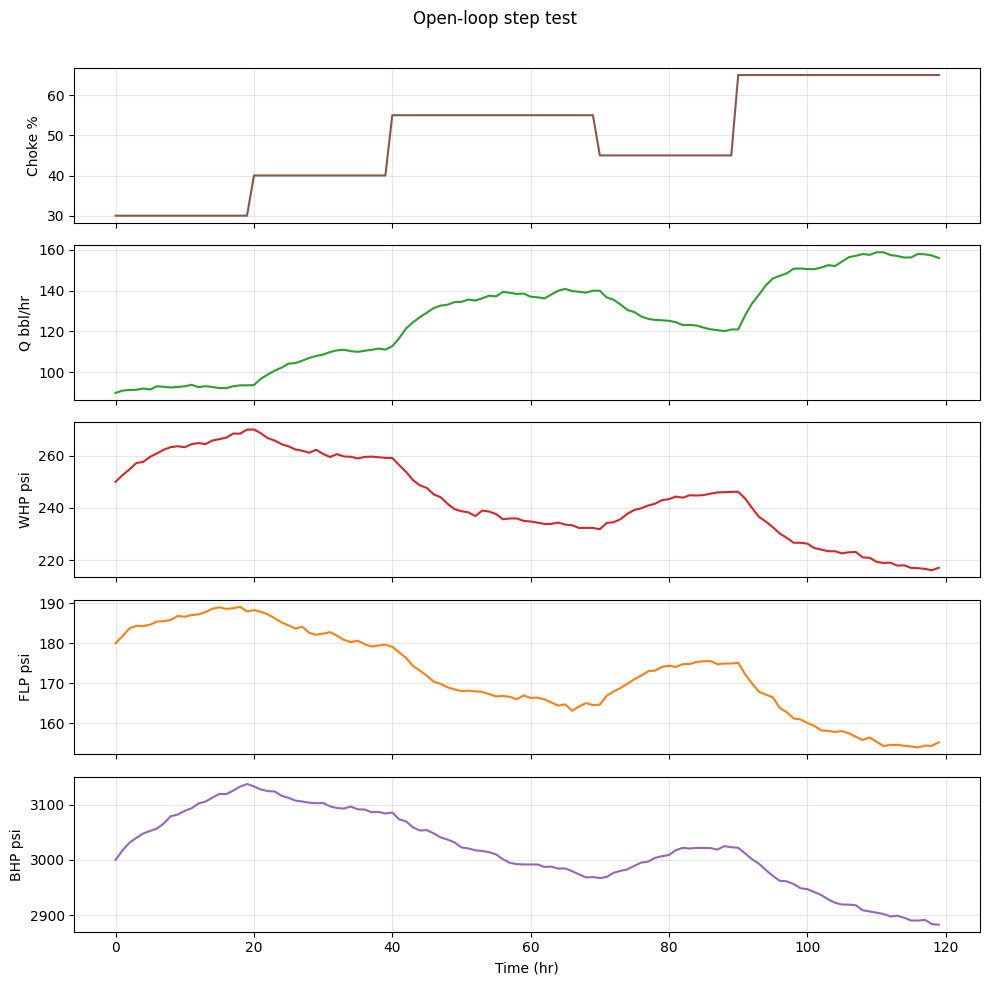

In [3]:
canon = to_canonical(df)
fig, ax = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
ax[0].plot(canon.t, canon.u, color='tab:brown'); ax[0].set_ylabel('Choke %')
ax[1].plot(canon.t, canon.Q, color='tab:green'); ax[1].set_ylabel('Q bbl/hr')
ax[2].plot(canon.t, canon.WHP, color='tab:red'); ax[2].set_ylabel('WHP psi')
ax[3].plot(canon.t, canon.FLP, color='tab:orange'); ax[3].set_ylabel('FLP psi')
ax[4].plot(canon.t, canon.BHP, color='tab:purple'); ax[4].set_ylabel('BHP psi')
ax[4].set_xlabel('Time (hr)')
for a in ax: a.grid(alpha=0.3)
fig.suptitle('Open-loop step test'); fig.tight_layout(rect=(0,0,1,0.97)); plt.show()

**Two facts that drive the whole design:**

1. The response is **first-order** (time constant ~5 hr on oil rate), with mild
   noise.
2. **Opening the choke raises oil rate but lowers every pressure** — so the
   binding safety constraints are *lower* bounds on the pressures, approached
   exactly when we push for more production.

## 2. Dynamic model identification — ARX(1) by least squares

For each output *y*, fit `y[k+1] = a·y[k] + (1−a)·(b0 + b1·u[k])`. This is linear
in the parameters, so we regress `y[k+1]` on `[y[k], 1, u[k]]` by OLS and read
off the steady-state gain `b1`, intercept `b0`, and time constant
`τ = −Ts/ln(a)`.

In [4]:
models = identify_all(df, Ts=ts)
print(format_report(models))

Identified ARX(1) models:  y[k+1] = a*y[k] + (1-a)*(b0 + b1*u[k])
--------------------------------------------------------------------
output       a     gain b1          b0   tau (hr)   noise sd
--------------------------------------------------------------------
Q       0.8237      1.8150      39.309       5.15      0.742
WHP     0.8892     -1.5857     319.387       8.52      0.667
FLP     0.8625     -0.9861     219.269       6.76      0.522
BHP     0.9257     -8.3832    3417.352      12.96      2.949
--------------------------------------------------------------------


The signs match the physics (choke up → rate up, pressures down). Now we
**validate** with a free-run: initialise each model once and simulate it
open-loop under the recorded choke sequence using *only its own predictions*.

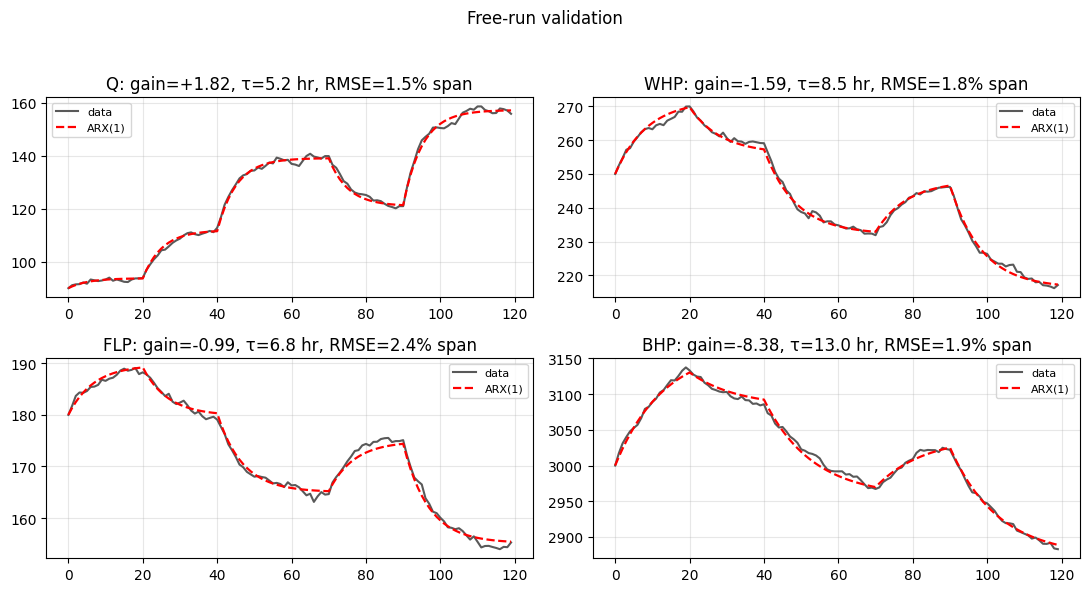

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, name in zip(axes.flat, OUTPUTS):
    y = canon[name].to_numpy(float)
    ysim = free_run(models[name], canon.u.to_numpy(float), y0=y[0])
    ax.plot(canon.t, y, color='0.35', label='data')
    ax.plot(canon.t, ysim, 'r--', lw=1.6, label='ARX(1)')
    v = validation_fit(models[name], df)
    ax.set_title(f"{name}: gain={models[name].gain:+.2f}, "
                 f"τ={models[name].tau_hr:.1f} hr, RMSE={v['rmse_pct_of_span']:.1f}% span")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle('Free-run validation'); fig.tight_layout(rect=(0,0,1,0.95)); plt.show()

The free-run tracks the data to 1.5–2.4 % of signal span across all four
outputs — a solid first-order fit. The residual standard deviations become the
noise level of the plant simulator.

## 3. Operating envelope (documented assumption)

The brief gives no numeric envelope, so we adopt limits chosen so the max safe
rate sits high in the observed range and Scenario C is clearly infeasible. All
constraints live in `envelope.py` — the single source of truth.

In [6]:
print(f"WHP_min={ENV.WHP_min}  FLP_min={ENV.FLP_min}  BHP_min={ENV.BHP_min} psi")
print(f"choke in [{ENV.choke_min},{ENV.choke_max}] %, ramp <= {ENV.max_ramp} %/step")

whp, q = models['WHP'], models['Q']
u_bind = (whp.b0 - ENV.WHP_min) / (-whp.b1)
print(f"\nWHP hits {ENV.WHP_min} psi at choke {u_bind:.1f}% "
      f"-> hard max safe rate ~{q.steady_state(u_bind):.0f} bbl/hr (WHP binds first)")

WHP_min=215.0  FLP_min=150.0  BHP_min=2850.0 psi
choke in [0.0,100.0] %, ramp <= 5.0 %/step

WHP hits 215.0 psi at choke 65.8% -> hard max safe rate ~159 bbl/hr (WHP binds first)


## 4. The safety-first predictive controller

Each interval the controller (`ChokeMPC`):

1. reads current Q, WHP, FLP, BHP and choke;
2. enumerates candidate moves (choke ± up to 5 %, fine grid — ramp-feasible);
3. predicts each candidate's pressure trajectory **and** steady state with the
   ARX models, and **rejects** any that would breach a bound + safety margin;
4. among safe candidates, minimises `(Q_ss − target)² + λ·Δchoke²`.

Because a first-order response moves *monotonically* to its steady state, proving
steady-state feasibility proves the whole trajectory safe — so the controller
never commands a move it hasn't shown to be safe. When the target is unreachable,
every safe candidate has `Q_ss < target`, so the same cost automatically settles
at the highest safe rate.

In [7]:
ctrl = ChokeMPC(models)
print("Per-pressure safety margins (psi):",
      {k: round(v, 2) for k, v in ctrl.margins.items()})

Per-pressure safety margins (psi): {'WHP': 2.67, 'FLP': 2.09, 'BHP': 11.8}


## 5. Closed-loop scenarios

We run the three required scenarios against `WellSimulator` (a stand-in with the
official simulator's `.step(choke) -> (Q, WHP, FLP, BHP)` signature) and, for
comparison, a naive envelope-unaware baseline.

In [8]:
mpc = run_all_mpc(models, envelope=ENV)
naive = run_all_baseline(models, envelope=ENV)

rows = []
for name in ('A', 'B', 'C'):
    m = mpc[name].metrics
    rows.append({
        'scenario': name,
        'target': m['final_target_bbl_hr'],
        'settled_Q': m['settled_oil_rate_bbl_hr'],
        'settled_choke': m['settled_choke_pct'],
        'MPC_violations': m['violations_total'],
        'naive_violations': naive[name].metrics['violations_total'],
        'min_WHP': m['min_pressures_psi']['WHP'],
    })
pd.DataFrame(rows).set_index('scenario')

,target,settled_Q,settled_choke,MPC_violations,naive_violations,min_WHP
scenario,,,,,,
A,130.0,129.89,50.00,0,0,238.78
B,150.0,149.66,61.00,0,0,221.93
C,185.0,154.85,63.95,0,168,216.69


### Scenario A — Startup → Target (130 bbl/hr)

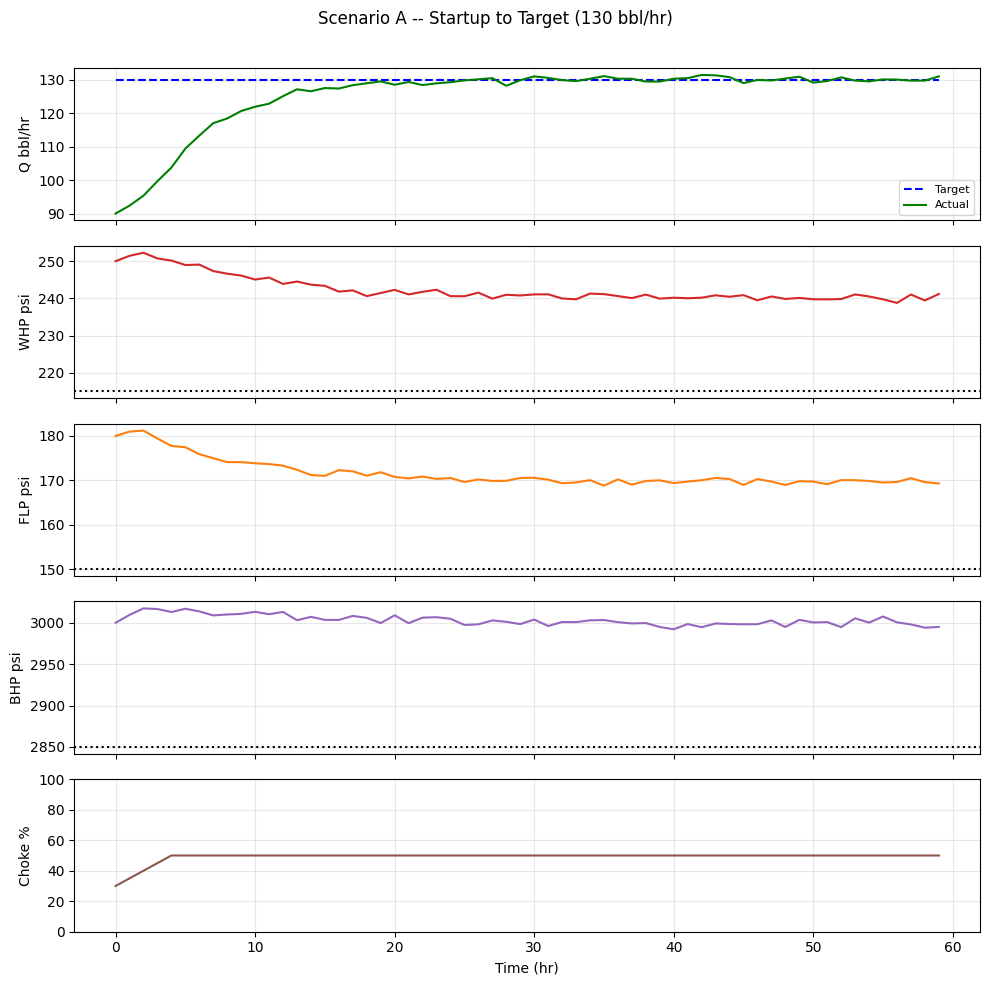

violations: 0 | worst pressure margin: 18.81 psi


In [9]:
res = mpc['A']
fig, ax = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
ax[0].plot(res.t, res.target, 'b--', label='Target'); ax[0].plot(res.t, res.Q, 'g', label='Actual')
ax[0].set_ylabel('Q bbl/hr'); ax[0].legend(fontsize=8)
for a, nm, c in zip(ax[1:4], ('WHP','FLP','BHP'), ('tab:red','tab:orange','tab:purple')):
    a.plot(res.t, getattr(res, nm), color=c); a.axhline(ENV.pressure_mins()[nm], color='k', ls=':')
    a.set_ylabel(nm+' psi')
ax[4].plot(res.t, res.u, color='tab:brown'); ax[4].set_ylabel('Choke %'); ax[4].set_ylim(0,100)
ax[4].set_xlabel('Time (hr)')
for a in ax: a.grid(alpha=0.3)
fig.suptitle(res.title); fig.tight_layout(rect=(0,0,1,0.97)); plt.show()
print('violations:', res.metrics['violations_total'],
      '| worst pressure margin:', res.metrics['worst_pressure_margin_psi'], 'psi')

Brings the well from startup to 130 bbl/hr and holds it, with pressure
headroom to spare and zero violations.

### Scenario B — Target Tracking (100 → 150 bbl/hr)

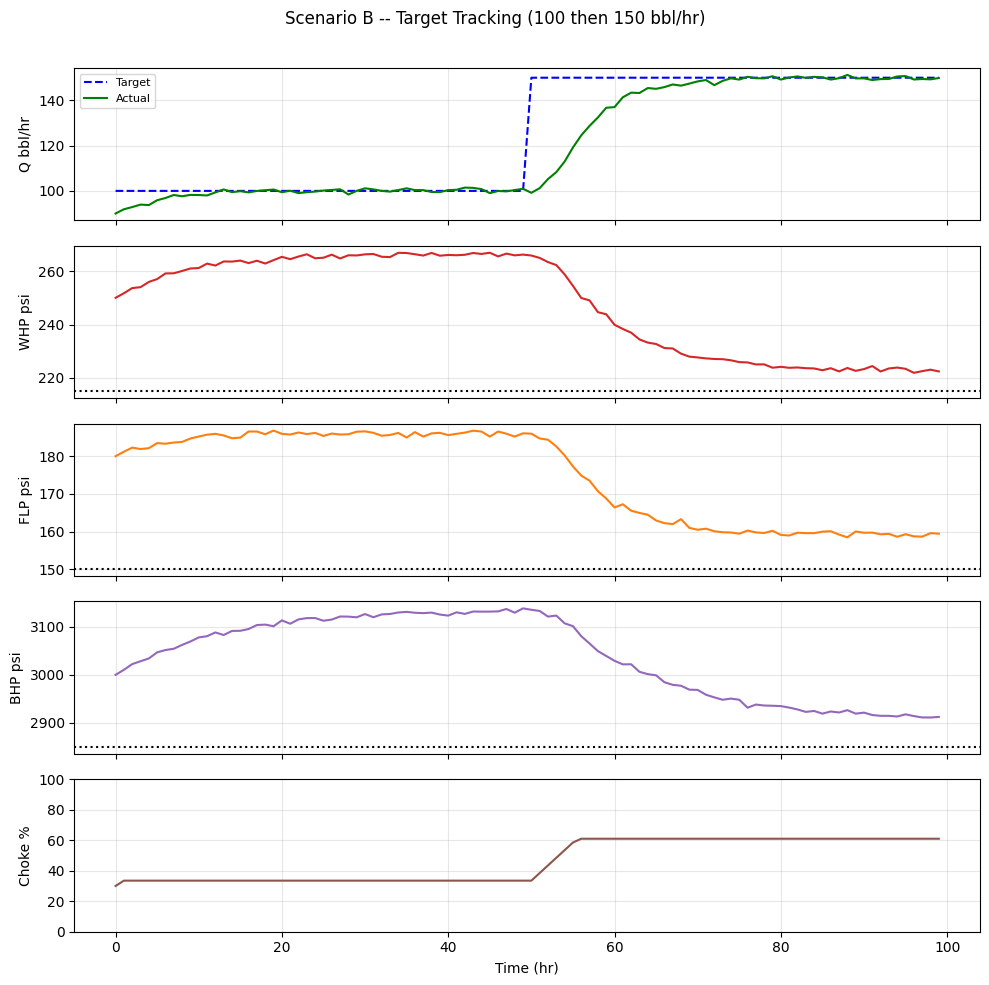

violations: 0 | worst pressure margin: 6.93 psi


In [10]:
res = mpc['B']
fig, ax = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
ax[0].plot(res.t, res.target, 'b--', label='Target'); ax[0].plot(res.t, res.Q, 'g', label='Actual')
ax[0].set_ylabel('Q bbl/hr'); ax[0].legend(fontsize=8)
for a, nm, c in zip(ax[1:4], ('WHP','FLP','BHP'), ('tab:red','tab:orange','tab:purple')):
    a.plot(res.t, getattr(res, nm), color=c); a.axhline(ENV.pressure_mins()[nm], color='k', ls=':')
    a.set_ylabel(nm+' psi')
ax[4].plot(res.t, res.u, color='tab:brown'); ax[4].set_ylabel('Choke %'); ax[4].set_ylim(0,100)
ax[4].set_xlabel('Time (hr)')
for a in ax: a.grid(alpha=0.3)
fig.suptitle(res.title); fig.tight_layout(rect=(0,0,1,0.97)); plt.show()
print('violations:', res.metrics['violations_total'],
      '| worst pressure margin:', res.metrics['worst_pressure_margin_psi'], 'psi')

Tracks the mid-run target step; WHP lines out safely above its 215 psi
floor.

### Scenario C — Infeasible Target (185 bbl/hr)

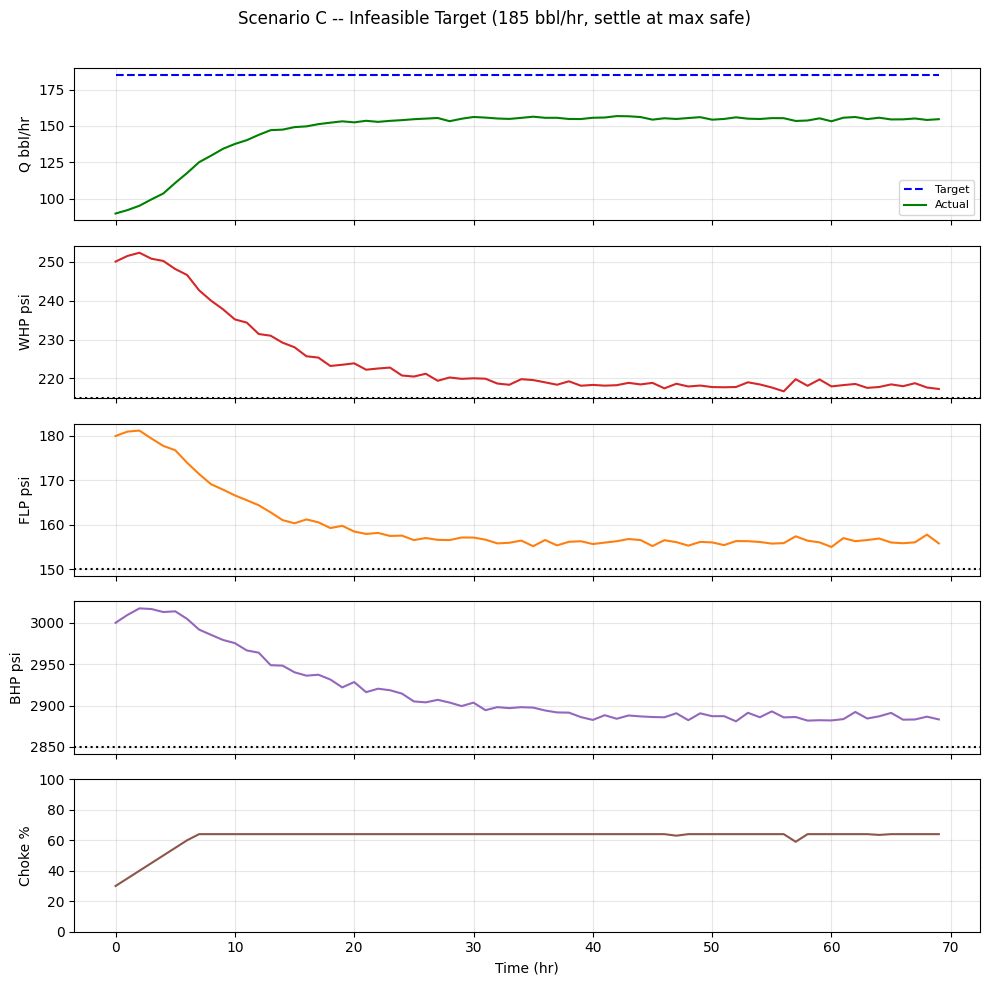

violations: 0 | worst pressure margin: 1.69 psi


In [11]:
res = mpc['C']
fig, ax = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
ax[0].plot(res.t, res.target, 'b--', label='Target'); ax[0].plot(res.t, res.Q, 'g', label='Actual')
ax[0].set_ylabel('Q bbl/hr'); ax[0].legend(fontsize=8)
for a, nm, c in zip(ax[1:4], ('WHP','FLP','BHP'), ('tab:red','tab:orange','tab:purple')):
    a.plot(res.t, getattr(res, nm), color=c); a.axhline(ENV.pressure_mins()[nm], color='k', ls=':')
    a.set_ylabel(nm+' psi')
ax[4].plot(res.t, res.u, color='tab:brown'); ax[4].set_ylabel('Choke %'); ax[4].set_ylim(0,100)
ax[4].set_xlabel('Time (hr)')
for a in ax: a.grid(alpha=0.3)
fig.suptitle(res.title); fig.tight_layout(rect=(0,0,1,0.97)); plt.show()
print('violations:', res.metrics['violations_total'],
      '| worst pressure margin:', res.metrics['worst_pressure_margin_psi'], 'psi')

185 bbl/hr would need choke ~80 % and drive WHP below 215 psi. The
controller **refuses**, settling at the maximum safe rate with zero violations.

### Safety performance: MPC vs. naive baseline on Scenario C

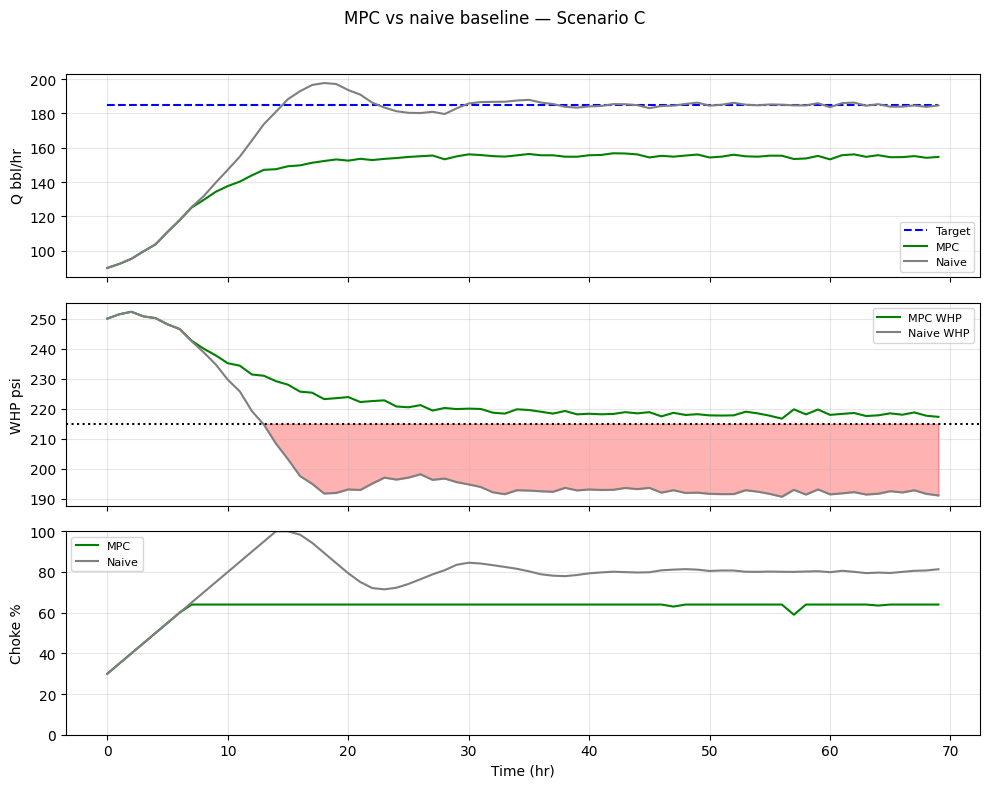

MPC violations: 0 | naive violations: 168


In [12]:
res, nz = mpc['C'], naive['C']
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
ax[0].plot(res.t, res.target, 'b--', label='Target'); ax[0].plot(res.t, res.Q, 'g', label='MPC')
ax[0].plot(res.t, nz.Q, color='tab:gray', label='Naive'); ax[0].set_ylabel('Q bbl/hr'); ax[0].legend(fontsize=8)
ax[1].plot(res.t, res.WHP, 'g', label='MPC WHP'); ax[1].plot(res.t, nz.WHP, color='tab:gray', label='Naive WHP')
ax[1].axhline(ENV.WHP_min, color='k', ls=':'); nwhp = np.asarray(nz.WHP)
ax[1].fill_between(res.t, ENV.WHP_min, nwhp, where=nwhp<ENV.WHP_min, color='red', alpha=0.3)
ax[1].set_ylabel('WHP psi'); ax[1].legend(fontsize=8)
ax[2].plot(res.t, res.u, 'g', label='MPC'); ax[2].plot(res.t, nz.u, color='tab:gray', label='Naive')
ax[2].set_ylabel('Choke %'); ax[2].set_ylim(0,100); ax[2].legend(fontsize=8); ax[2].set_xlabel('Time (hr)')
for a in ax: a.grid(alpha=0.3)
fig.suptitle('MPC vs naive baseline — Scenario C'); fig.tight_layout(rect=(0,0,1,0.96)); plt.show()
print('MPC violations:', res.metrics['violations_total'],
      '| naive violations:', nz.metrics['violations_total'])

The naive controller chases the infeasible target, drives the choke past
100 %, and holds the well ~65 psi below the WHP floor for the whole run — 168
constraint breaches — to gain ~30 bbl/hr of unsafe production. The safety-first
controller gives that up **by design**.

## 6. Conclusion

- A first-order ARX(1) model, identified by OLS, captures the well to ~2 % of
  span.
- Exploiting the monotonicity of that model makes a lightweight brute-force MPC
  **provably safe**: it only commands moves it has shown keep the well inside the
  envelope.
- Across all three scenarios: **zero envelope violations**; feasible targets
  (A, B) tracked to <0.4 bbl/hr; the infeasible target (C) handled by settling at
  the maximum safe rate — where a naive controller breaches 168 times.

`simulator.WellSimulator` shares the official `.step()` signature, so the real
event simulator drops in with a one-line change; the envelope is a single
editable module.